# FreeSurfer 4: within-subject retest analysis

We have a series of notebooks to demonstrate some standard analyses with FreeSurfer.  
This notebooks shows how to run a retest analysis with two sessions on the individual level. This approach is applicable to any kind of two-session within-subject data, i.e. it could be a placebo-treatment dataset, any other kind of intervention, or a longitudinal study. 

Here, we will, in our main analysis ignore the CB/HC group effect but focus on the developmental effect only. With about 20 years of baseline age and a 3-year follow-up interval this results in a study of adolescent-to-adulthood brain development in the "latest" stage (assuming a prolonged neurodevelopmental phase until about 25-30 years).

The data was prepared in the [data preparation notebook](freesurfer_1_prepare.ipynb).

In [1]:
from pathlib import Path
path = "/Users/llotter/projects/nispace/pascal_maps"
paths = list(Path(path).glob("*"))


In [2]:
# general imports
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# monkey patch to make progress bars show as ASCII instead of as widgets
import tqdm.notebook
tqdm.notebook.tqdm = tqdm.tqdm
tqdm = tqdm.notebook.tqdm

In [3]:
# load local nispace, for testing
# COMMENT THIS OUT IF YOU RUN THIS LOCALLY AFTER INSTALLING NISPACE
import sys
sys.path.append("/Users/llotter/projects/nispace/")

In [12]:
from nispace.datasets import fetch_reference
fetch_reference(
    dataset="pet",
    maps=["target-5HT1a_tracer-cumi101_n-8_dx-hc_pub-beliveau2017"],
    space="MNI152NLin2009cAsym"
    
)

INFO | 16/04/26 16:08:54 | nispace: Loading pet maps.
INFO | 16/04/26 16:08:54 | nispace: Applying filter: ['target-5HT1a_tracer-cumi101_n-8_dx-hc_pub-beliveau2017']
INFO | 16/04/26 16:08:54 | nispace: Filtered from 49 to 1 maps.
The NiSpace "PET" dataset is based on openly available nuclear imaging maps largely accessed via neuromaps 
(https://neuromaps-main.readthedocs.io/). If requested in the varying original spaces and resolutions (termed "MNI152", 
"fsaverageOriginal", or "fsLROriginal"), the maps are downloaded directly from the source and cached locally. If, as is highly 
recommended, the maps are requested in a defined space ("MNI152NLin2009cAsym", "MNI152NLin6Asym", "fsaverage", or "fsLR"), 
they are downloaded from the NiSpace-data GitHub repo (find them in `~HOME/nispace-data/reference/pet/map`). 
The NiSpace-hosted MNI maps were directly registered to 2mm MNI152NLin6Asym space, and transformed to 2mm MNI152NLin2009cAsym 
with a pre-estimated MNI-to-MNI transformation using

[PosixPath('/Users/llotter/nispace-data/reference/pet/map/target-5HT1a_tracer-cumi101_n-8_dx-hc_pub-beliveau2017/target-5HT1a_tracer-cumi101_n-8_dx-hc_pub-beliveau2017_space-MNI152NLin2009cAsym.nii.gz')]

## Load data

We prepared the data before and will only load the longitudinal data for the HC group.

In [3]:
# cortical thickness data
df_cortex = pd.read_csv(Path.cwd() / "freesurfer_ct_all.csv", index_col=[0,1])

# covariates
df_covariates = pd.read_csv(Path.cwd() / "freesurfer_cov_all.csv", index_col=[0,1])

# participants df
df_participants = pd.read_csv(Path.cwd() / "freesurfer_participants.csv", index_col=0)
# subset to available subjects
# here, the imaging data contains two rows per subject (i.e.: two sessions); this kind of indexing
# will duplicate each subject row in the original df_particpants
df_participants = df_participants.loc[df_cortex.index.get_level_values("subject")]
# now, we just copy the index of the imaging data, adding the sessins column
df_participants.index = df_cortex.index

In [14]:
df_participants["group"]

subject  session
sub-101  ses-BL     CB
         ses-FU     CB
sub-103  ses-BL     CB
         ses-FU     CB
sub-104  ses-BL     CB
                    ..
sub-318  ses-FU     HC
sub-319  ses-BL     HC
         ses-FU     HC
sub-320  ses-BL     HC
         ses-FU     HC
Name: group, Length: 80, dtype: object

In [39]:
# difference BL-FU
nsp_object.transform_y(
    "elemdiff(a,b)", 
    subjects=df_participants.index.get_level_values("subject"),
    groups=df_participants.index.get_level_values("session").map({"ses-BL": "a", "ses-FU": "b"})
)
# group difference
nsp_object.transform_y(
    "zscore(a,b)", 
    Y=nsp_object.get_y(Y_transform="elemdiff(a,b)"),
    groups=df_participants["group"].loc[:, "ses-BL"].map({"HC": "a", "CB": "b"})
)
# 
nsp_object.permute("groups", Y_transform="zscore(a,b)", groups=df_participants["group"].loc[:, "ses-BL"].map({"HC": "a", "CB": "b"}))

INFO | 10/04/26 12:07:22 | nispace: *** NiSpace.transform_y() - Y transformation and comparison. ***
INFO | 10/04/26 12:07:22 | nispace: Groups/sessions vector provided, ensuring dummy-coding.
INFO | 10/04/26 12:07:22 | nispace: Subjects vector provided, validating.
INFO | 10/04/26 12:07:22 | nispace: Applying Y transform 'elemdiff(a,b)'.
INFO | 10/04/26 12:07:22 | nispace: Returning Y dataframe: 
| Y_TRANSFORM   | 
| elemdiff(a,b) | 
INFO | 10/04/26 12:07:22 | nispace: *** NiSpace.transform_y() - Y transformation and comparison. ***
INFO | 10/04/26 12:07:22 | nispace: Groups/sessions vector provided, ensuring dummy-coding.
INFO | 10/04/26 12:07:22 | nispace: Applying Y transform 'zscore(a,b)'.
INFO | 10/04/26 12:07:22 | nispace: *** NiSpace.permute() - Estimate exact non-parametric p values. ***
INFO | 10/04/26 12:07:22 | nispace: Permutation of: Y groups.
WARNING | 10/04/26 12:07:22 | nispace: 'spearman' colocalization was not run before. Running now.
INFO | 10/04/26 12:07:22 | nispa

Colocalizing (spearman, -1 proc): 100%|██████████| 21/21 [00:05<00:00,  3.60it/s]

INFO | 10/04/26 12:07:28 | nispace: Loading transformed Y data, transform = 'zscore(a,b)'.
INFO | 10/04/26 12:07:28 | nispace: Will calculate p values for mean calculation across Y maps. Set 'p_from_average_y_coloc' = False to change this behavior.
INFO | 10/04/26 12:07:28 | nispace: Loading observed colocalizations (method = 'spearman').
INFO | 10/04/26 12:07:28 | nispace: Generating permuted Y groups.


IndexError: boolean index did not match indexed array along axis 0; size of axis is 80 but size of corresponding boolean axis is 40

In [16]:
help(nsp_object.transform_y)

Help on method transform_y in module nispace.api:

transform_y(transform, groups=None, subjects=None, Y=None, Y_name='Y', store=True, verbose=None) method of nispace.api.NiSpace instance



## Perform colocalization with individual difference between time points.

Only cortical thickness data here.  
This will be similar to the prior notebooks but again with a different setting for comparison_method.  
The function will now calculate the raw parcel-wise change for every subject between its baseline and follow-up scan, resulting in one vector of colocalization values for every subject. We run this across all subjects and include the clinical grouping variable as a covarate to regress. This would be the equivalent of the "main effect of time" in a mixed linear model.

We will observe a particular result: In this analysis, we have highly significant outcomes because the input data is very homogenuous. We

subjects groups clinical_group_to_regress    age     sex  \
subject session                                                            
sub-101 ses-BL   sub-101      a                        CB  24.44    male   
        ses-FU   sub-101      b                        CB  24.44    male   
sub-103 ses-BL   sub-103      a                        CB  24.33    male   
        ses-FU   sub-103      b                        CB  24.33    male   
sub-104 ses-BL   sub-104      a                        CB  17.90  female   

                         eTIV  
subject session                
sub-101 ses-BL   1.562223e+06  
        ses-FU   1.585093e+06  
sub-103 ses-BL   1.692744e+06  
        ses-FU   1.715033e+06  
sub-104 ses-BL   1.384595e+06

INFO | 10/04/26 11:26:42 | nispace: Using integrated parcellation Desikan.
INFO | 10/04/26 11:26:42 | nispace: Loading integrated pet dataset as X data.
INFO | 10/04/26 11:26:42 | nispace: Using collection UniqueTracers.
INFO | 10/04/26 11:26:42 | nispace: Loading pet maps.
INFO | 10/04/26 11:26:42 | nispace: Loading integrated collection 'UniqueTracers' for dataset 'pet'.
INFO | 10/04/26 11:26:42 | nispace: Filtering maps by collection.
INFO | 10/04/26 11:26:42 | nispace: Loading data parcellated with 'DesikanKilliany'
The NiSpace "PET" dataset is based on openly available nuclear imaging maps largely accessed via neuromaps 
(https://neuromaps-main.readthedocs.io/). If requested in the varying original spaces and resolutions (termed "MNI152", 
"fsaverageOriginal", or "fsLROriginal"), the maps are downloaded directly from the source and cached locally. If, as is highly 
recommended, the maps are requested in a defined space ("MNI152NLin2009cAsym", "MNI152NLin6Asym", "fsaverage", or "fs

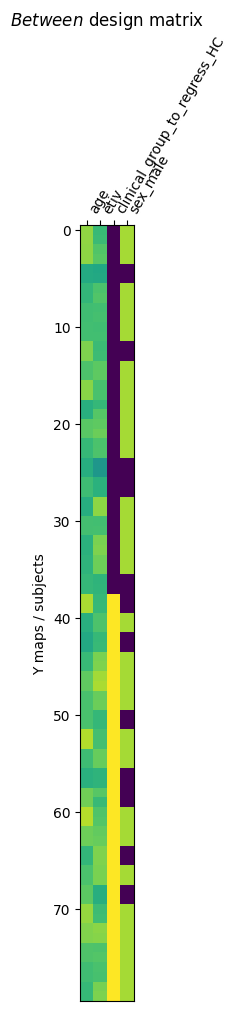

INFO | 10/04/26 11:26:42 | nispace: Regressing 4 between covariate(s) from Y.


Regressing 4 between covariate(s) from Y (-1 proc): 100%|██████████| 68/68 [00:09<00:00,  7.48it/s]


INFO | 10/04/26 11:26:51 | nispace: *** NiSpace.transform_y() - Y transformation and comparison. ***
INFO | 10/04/26 11:26:51 | nispace: Groups/sessions vector provided, ensuring dummy-coding.
INFO | 10/04/26 11:26:51 | nispace: Subjects vector provided, validating.
INFO | 10/04/26 11:26:51 | nispace: Applying Y transform 'elemdiff(a,b)'.
INFO | 10/04/26 11:26:51 | nispace: *** NiSpace.colocalize() - Estimating X & Y colocalizations. ***
INFO | 10/04/26 11:26:51 | nispace: Running 'spearman' colocalization with 'elemdiff(a,b)' transform.
INFO | 10/04/26 11:26:51 | nispace: Pre-ranking X and Y data.


Colocalizing (spearman, -1 proc): 100%|██████████| 40/40 [00:00<00:00, 128.57it/s]

INFO | 10/04/26 11:26:52 | nispace: *** NiSpace.permute() - Estimate exact non-parametric p values. ***
INFO | 10/04/26 11:26:52 | nispace: Permutation of: Y groups.
INFO | 10/04/26 11:26:52 | nispace: Loading transformed Y data, transform = 'elemdiff(a,b)'.
INFO | 10/04/26 11:26:52 | nispace: Will calculate p values for mean calculation across Y maps. Set 'p_from_average_y_coloc' = False to change this behavior.
INFO | 10/04/26 11:26:52 | nispace: Loading observed colocalizations (method = 'spearman').
INFO | 10/04/26 11:26:52 | nispace: Generating permuted Y groups.
INFO | 10/04/26 11:26:52 | nispace: Permuting groups/sessions vector, strategy: paired, proportional.



Null transformations (spearman, -1 proc): 100%|██████████| 10000/10000 [00:00<00:00, 33475.83it/s]


INFO | 10/04/26 11:26:53 | nispace: Pre-ranking X and Y (null) data.


Null colocalizations (spearman, -1 proc): 100%|██████████| 10000/10000 [00:05<00:00, 1817.71it/s]


INFO | 10/04/26 11:27:02 | nispace: Calculating exact p-values (tails = {'rho': 'two'}).
INFO | 10/04/26 11:27:02 | nispace: *** NiSpace.correct_p() - Correct p values for multiple comparisons. ***
INFO | 10/04/26 11:27:02 | nispace: *** NiSpace.plot() - Plot colocalization results. ***
INFO | 10/04/26 11:27:03 | nispace: Creating categorical plot for method spearman, colocalization stat rho.


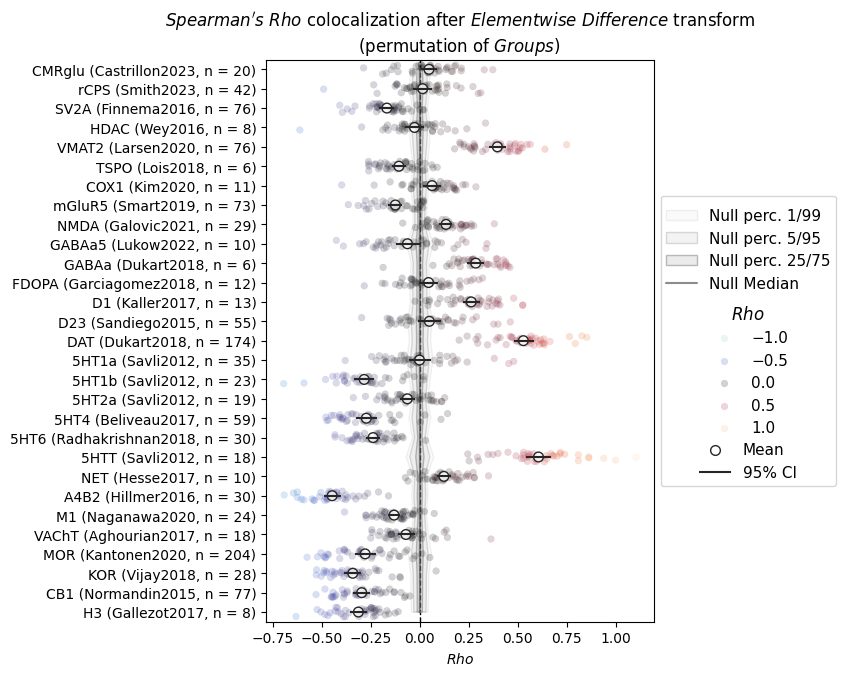

INFO | 10/04/26 11:27:04 | nispace: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM   | 
| spearman | False | False       | elemdiff(a,b) | 
INFO | 10/04/26 11:27:04 | nispace: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | NORM  | X_REDUCTION | Y_TRANSFORM   | 
| spearman | groups       | False | None      | False | False       | elemdiff(a,b) | 
INFO | 10/04/26 11:27:04 | nispace: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA  | MC_METHOD | NORM  | X_REDUCTION | Y_TRANSFORM   | 
| spearman | groups       | False | fdrbh     | False | False       | elemdiff(a,b) | 


In [ ]:
from nispace.workflows import group_comparison

# design with covariates
# note the difference: we supply a vector with the sessions to "groups" and an additional vector
# with one unique value per subject (id or name)
# the sessions info is here contained in the multi index copied to the participants df before
design = pd.DataFrame({
    "subjects": df_participants.index.get_level_values("subject"),
    "groups": df_participants.index.get_level_values("session").map({"ses-BL": "a", "ses-FU": "b"}), 
    "clinical_group_to_regress": df_participants["group"],
    "age": df_participants["age at baseline "], 
    "sex": df_participants["gender"], 
    "eTIV": df_covariates["EstimatedTotalIntraCranialVol"]
    # dont use euler number here: 
    # The dataset has a problem in that FU sessions have generally higher euler numbers, biasing the results
    #"euler_number": df_covariates["SurfaceHoles"]
})
display(design.head(5))

# run
colocs, pvalues, qvalues, nsp_object = group_comparison(
    y=df_cortex, # sample data
    x="pet", # reference data
    parcellation="Desikan", # parcellation
    design=design, # group membership
    paired=True,
    comparison_method="elemdiff(a,b)", # NOTE: paired settings available: pairedcohen, elemdiff, logfc, prc
    colocalization_method="spearman", # spearman correlation btw. each x and y
    n_perm=10000, # number of permutations for exact p values
    n_proc=-1, # number of cores to use (-1 = all available)
    verbose=True,
    seed=42
)

The outputs of the workflow function now are:
- `colocs`: the correlation coefficients between BL-FU-difference map for every subject and the reference maps
- `pvalues`: the p values calculated for the mean of the correlation coefficients, i.e., indexing the *longitudinal* effect.
- `qvalues`: the FDR-corrected p values for each correlation coefficient
- `nsp_object`: the NiSpace object, which contains the results and can be used for further analyses  

We will print the first three dataframes:

In [5]:
display("Colocalization:", colocs)
display("p values:", pvalues)
display("q values:", qvalues)

'Colocalization:'

set                                                            General  \
map             target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castrillon2023   
subject session                                                          
sub-101 ses-BL                                            0.007406       
sub-103 ses-BL                                            0.133552       
sub-104 ses-BL                                            0.212039       
sub-108 ses-BL                                           -0.133163       
sub-109 ses-BL                                            0.059428       
sub-112 ses-BL                                            0.055713       
sub-116 ses-BL                                            0.328968       
sub-117 ses-BL                                            0.015346       
sub-119 ses-BL                                           -0.006146       
sub-121 ses-BL                                            0.372336       
sub-123 ses-BL                                           -0.145422       
sub-124 ses-BL                                           -0.111426       
sub-125 ses-BL                                            0.176723       
sub-126 ses-BL                                            0.161249       
sub-127 ses-BL                                            0.009162       
sub-128 ses-BL                                           -0.019241       
sub-130 ses-BL                                           -0.036700       
sub-132 ses-BL                                            0.182675       
sub-133 ses-BL                                            0.045189       
sub-202 ses-BL                                            0.007100       
sub-206 ses-BL                                            0.051808       
sub-207 ses-BL                                            0.166856       
sub-209 ses-BL                                            0.053684       
sub-211 ses-BL                                            0.097803       
sub-213 ses-BL                                            0.008016       
sub-218 ses-BL                                            0.135962       
sub-222 ses-BL                                            0.038879       
sub-302 ses-BL                                            0.093026       
sub-304 ses-BL                                           -0.113668       
sub-305 ses-BL                                           -0.171726       
sub-306 ses-BL                                           -0.039032       
sub-308 ses-BL                                            0.211161       
sub-309 ses-BL                                            0.097957       
sub-311 ses-BL                                            0.141954       
sub-313 ses-BL                                            0.050622       
sub-314 ses-BL                                            0.042320       
sub-316 ses-BL                                           -0.287551       
sub-318 ses-BL                                            0.076033       
sub-319 ses-BL                                            0.080334       
sub-320 ses-BL                                           -0.190103       

set                                                                  \
map             target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith2023   
subject session                                                       
sub-101 ses-BL                                           -0.120634    
sub-103 ses-BL                                            0.210363    
sub-104 ses-BL                                            0.137712    
sub-108 ses-BL                                           -0.235467    
sub-109 ses-BL                                           -0.048058    
sub-112 ses-BL                                            0.023404    
sub-116 ses-BL                                            0.271019    
sub-117 ses-BL                                            0.078414    
sub-119 ses-BL                      

'p values:'

set                                                 General  \
map  target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castrillon2023   
mean                                              0.024       

set                                                       \
map  target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith2023   
mean                                             0.5618    

set                                                      \
map  target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016   
mean                                             0.0001   

set                                                        \
map  target-HDAC_tracer-martinostat_n-8_dx-hc_pub-wey2016   
mean                                             0.2826     

set                                                      \
map  target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020   
mean                                             0.0001   

set                                         Immunity  \
map  target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018   
mean                                          0.0001   

set                                                  \
map  target-COX1_tracer-ps13_n-11_dx-hc_pub-kim2020   
mean                                          0.001   

set                                             Glutamate  \
map  target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019   
mean                                             0.0001     

set                                                       \
map  target-NMDA_tracer-ge179_n-29_dx-hc_pub-galovic2021   
mean                                             0.0001    

set                                                    GABA  ...  \
map  target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lukow2022  ...   
mean                                             0.0288      ...   

set                                                      Serotonin  \
map  target-5HT6_tracer-gsk215083_n-30_dx-hc_pub-radhakrishnan2018   
mean                                             0.0001              

set                                                    \
map  target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012   
mean                                           0.0001   

set                     Noradrenaline/Acetylcholine  \
map  target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017   
mean                                         0.0001   

set                                                           \
map  target-A4B2_tracer-flubatine_n-30_dx-hc_pub-hillmer2016   
mean                                             0.0001        

set                                                           \
map  target-M1_tracer-lsn3172176_n-24_dx-hc_pub-naganawa2020   
mean                                             0.0001        

set                                                          \
map  target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017   
mean                                             0.0001       

set                                     Opiods/Endocannabinoids  \
map  target-MOR_tracer-carfentanil_n-204_dx-hc_pub-kantonen2020   
mean                                             0.0001           

set                                                        \
map  target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018   
mean                                             0.0001     

set                                                       \
map  target-CB1_tracer-omar_n-77_dx-hc_pub-normandin2015   
mean                                             0.0001    

set                                              Histamine  
map  target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017  
mean                                             0.0001     

[1 rows x 29 columns]

'q values:'

set                                                 General  \
map  target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castrillon2023   
mean                                           0.030261       

set                                                       \
map  target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith2023   
mean                                           0.581864    

set                                                      \
map  target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016   
mean                                           0.000138   

set                                                        \
map  target-HDAC_tracer-martinostat_n-8_dx-hc_pub-wey2016   
mean                                           0.303533     

set                                                      \
map  target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020   
mean                                           0.000138   

set                                         Immunity  \
map  target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018   
mean                                        0.000138   

set                                                  \
map  target-COX1_tracer-ps13_n-11_dx-hc_pub-kim2020   
mean                                       0.001318   

set                                             Glutamate  \
map  target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019   
mean                                           0.000138     

set                                                       \
map  target-NMDA_tracer-ge179_n-29_dx-hc_pub-galovic2021   
mean                                           0.000138    

set                                                    GABA  ...  \
map  target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lukow2022  ...   
mean                                             0.0348      ...   

set                                                      Serotonin  \
map  target-5HT6_tracer-gsk215083_n-30_dx-hc_pub-radhakrishnan2018   
mean                                           0.000138              

set                                                    \
map  target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012   
mean                                         0.000138   

set                     Noradrenaline/Acetylcholine  \
map  target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017   
mean                                       0.000138   

set                                                           \
map  target-A4B2_tracer-flubatine_n-30_dx-hc_pub-hillmer2016   
mean                                           0.000138        

set                                                           \
map  target-M1_tracer-lsn3172176_n-24_dx-hc_pub-naganawa2020   
mean                                           0.000138        

set                                                          \
map  target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017   
mean                                           0.000138       

set                                     Opiods/Endocannabinoids  \
map  target-MOR_tracer-carfentanil_n-204_dx-hc_pub-kantonen2020   
mean                                           0.000138           

set                                                        \
map  target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018   
mean                                           0.000138     

set                                                       \
map  target-CB1_tracer-omar_n-77_dx-hc_pub-normandin2015   
mean                                           0.000138    

set                                              Histamine  
map  target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017  
mean                                           0.000138     

[1 rows x 29 columns]